In [ ]:
'''Stepl :
step 2:
Step 3:
step 5:
Step 6:
Load required libraries
load the data
Data Exploration
Data Visualisation
divide the data intro train and testing
Applying machine leraning algorithms'''

'Stepl :\nstep 2:\nStep 3:\nstep 5:\nStep 6:\nLoad required libraries\nload the data\nData Exploration\nData Visualisation\ndivide the data intro train and testing\nApplying machine leraning algorithms'

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt #visualizations
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

CRIM: per capita crime rate by town

ZN: proportion of residential land zoned for lots over 25,000 sq.ft.

INDUS: proportion of non-retail business acres per town

CHAS: Charles River dummy variable (1 if tract bounds river; 0 otherwise)

NOX: nitric oxides concentration (parts per 10 million)

RM: average number of rooms per dwelling

AGE: proportion of owner-occupied units built prior to 1940

DIS: weighted distances to five Boston employment centres

RAD: index of accessibility to radial highways

TAX: full-value property-tax rate per ($10,000)

PTRATIO: pupil-teacher ratio by town

B: 1000(Bk - 0.63)^2 where Bk is the proportion of [people of African American descent] by town

LSTAT: % lower status of the population

MEDV: Median value of owner-occupied homes in $1000s (target variable)

In [ ]:
import pandas as pd
mydata = pd.read_csv('/content/Boston_HousingDataSet.xls')
mydata.head()

['.config', 'Boston_HousingDataSet.xls', 'sample_data']
Error loading data: Excel file format cannot be determined, you must specify an engine manually.
      CRIM    ZN  INDUS  CHAS     NX     RM   AGE     DIS  RAD  TAX  PTRATIO  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222     18.7   

        B  LSTAT  MEDV  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
3  394.63   2.94  33.4  
4  396.90   5.33  36.2  


In [ ]:
mydata=pd.read_csv('/content/Boston_HousingDataSet.xls')
mydata.head()

,CRIM,ZN,INDUS,CHAS,NX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [ ]:
mydata.shape

(506, 14)

In [ ]:
mydata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NX       506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


In [ ]:
mydata.isna().sum()

,0
CRIM,0
ZN,0
INDUS,0
CHAS,0
NX,0
RM,0
AGE,0
DIS,0
RAD,0
TAX,0


In [ ]:
mydata.describe().T

,count,mean,std,min,25%,50%,75%,max
CRIM,506.0,3.613524,8.601545,0.00632,0.082045,0.25651,3.677083,88.9762
ZN,506.0,11.363636,23.322453,0.00000,0.000000,0.00000,12.500000,100.0000
INDUS,506.0,11.136779,6.860353,0.46000,5.190000,9.69000,18.100000,27.7400
CHAS,506.0,0.069170,0.253994,0.00000,0.000000,0.00000,0.000000,1.0000
NX,506.0,0.554695,0.115878,0.38500,0.449000,0.53800,0.624000,0.8710
RM,506.0,6.284634,0.702617,3.56100,5.885500,6.20850,6.623500,8.7800
AGE,506.0,68.574901,28.148861,2.90000,45.025000,77.50000,94.075000,100.0000
DIS,506.0,3.795043,2.105710,1.12960,2.100175,3.20745,5.188425,12.1265
RAD,506.0,9.549407,8.707259,1.00000,4.000000,5.00000,24.000000,24.0000
TAX,506.0,408.237154,168.537116,187.00000,279.000000,330.00000,666.000000,711.0000


<Axes: xlabel='MEDV', ylabel='Count'>

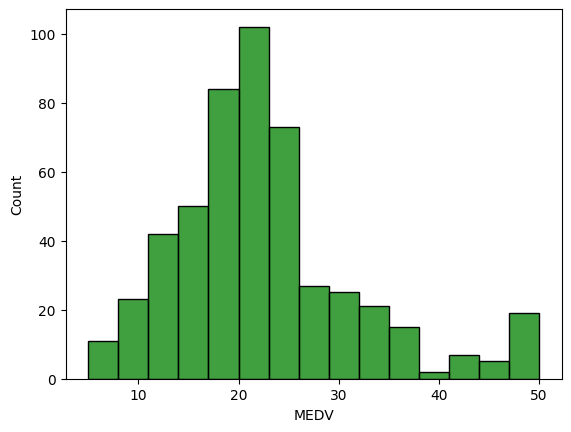

In [ ]:
#step 4 data visualizations
#histogram of target Variable
import seaborn as sns
sns.histplot(mydata['MEDV'], bins=15, color='green')

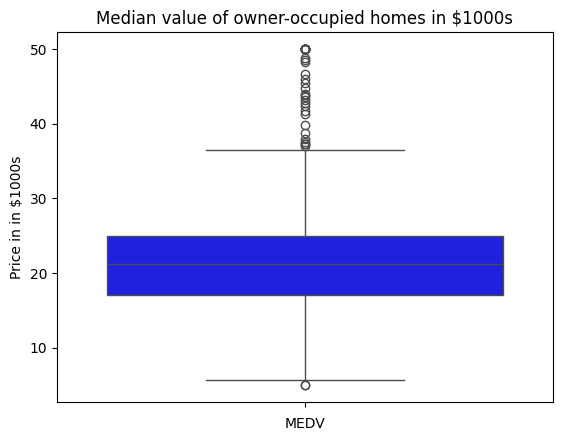

In [ ]:
sns.boxplot(mydata['MEDV'],color='blue')
plt.title("Median value of owner-occupied homes in $1000s")
plt.xlabel("MEDV")
plt.ylabel("Price in in $1000s")
plt.show()

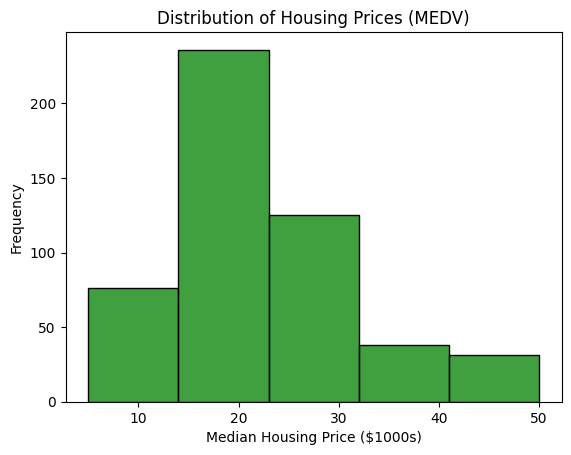

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histogram of Housing Prices (MEDV)
sns.histplot(mydata['MEDV'], bins=5, color='green')
#sns.histplot(mydata['MEDV'], bins=20, kde=True, color='green')
plt.title('Distribution of Housing Prices (MEDV)')
plt.xlabel('Median Housing Price ($1000s)')
plt.ylabel('Frequency')
plt.show()

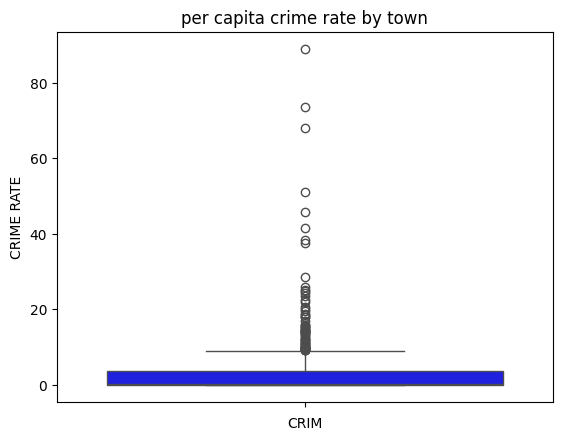

In [ ]:
### bosplot crime rate

sns.boxplot(mydata['CRIM'], color = "blue")

plt.title("per capita crime rate by town")

plt.xlabel("CRIM")

plt.ylabel("CRIME RATE")

plt.show()

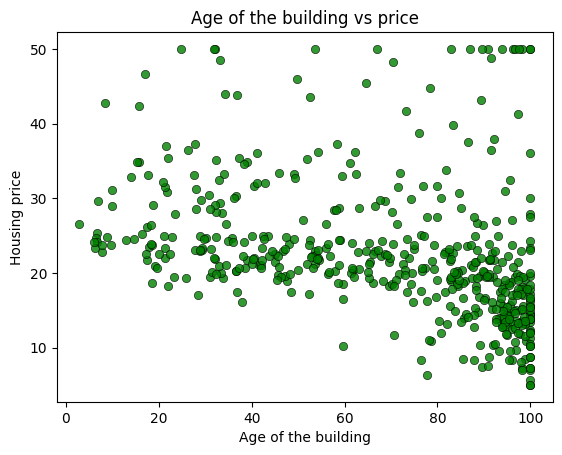

In [ ]:
# Scatter plots
sns.scatterplot(x= "AGE", y = "MEDV", data = mydata, color = "green",edgecolor='black', alpha = 0.8)
plt.title("Age of the building vs price")
plt.xlabel('Age of the building')
plt.ylabel('Housing price')
plt.show()

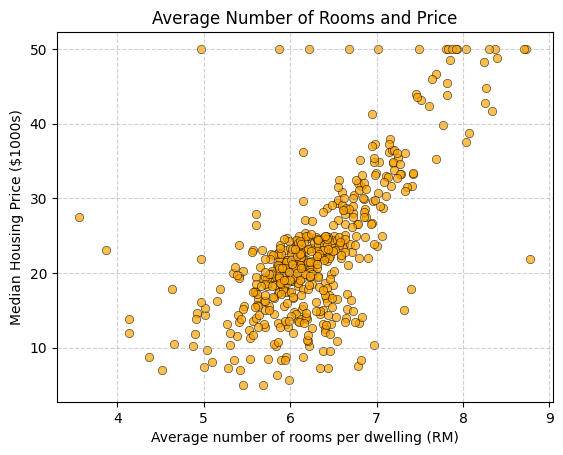

In [ ]:
# Scatter plot between RM and MEDV
sns.scatterplot(x='RM', y='MEDV', data=mydata, color='orange', edgecolor='black', alpha=0.7)
plt.title('Average Number of Rooms and Price')
plt.xlabel('Average number of rooms per dwelling (RM)')
plt.ylabel('Median Housing Price ($1000s)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

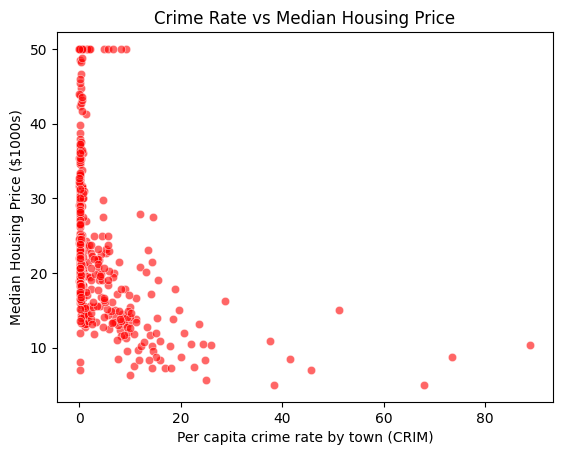

In [ ]:
# Scatter plot between CRIM and MEDV
sns.scatterplot(x='CRIM', y='MEDV', data=mydata, color='red', alpha=0.6)
plt.title('Crime Rate vs Median Housing Price')
plt.xlabel('Per capita crime rate by town (CRIM)')
plt.ylabel('Median Housing Price ($1000s)')
plt.show()

In [ ]:
#barplots average housing price by accessibility of road highways
rad_medv_mean=mydata.groupby("RAD")["MEDV"].mean().reset_index()
rad_medv_mean

,RAD,MEDV
0,1,24.365000
1,2,26.833333
2,3,27.928947
3,4,21.387273
4,5,25.706957
5,6,20.976923
6,7,27.105882
7,8,30.358333
8,24,16.403788


<Axes: xlabel='RAD', ylabel='MEDV'>

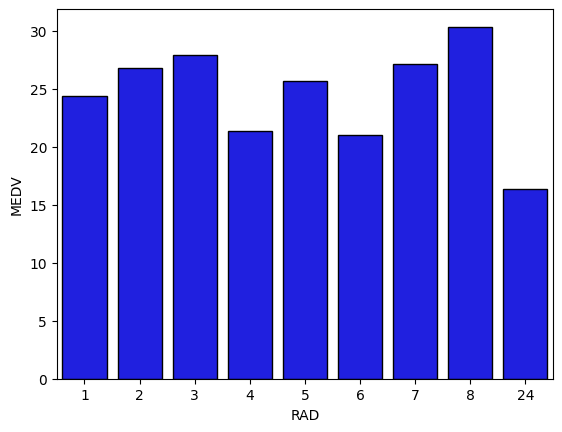

In [ ]:
# Bar plot: Average housing price by accessibility of radial highways
sns.barplot(x='RAD', y='MEDV', data=rad_medv_mean, color='blue', edgecolor='black')

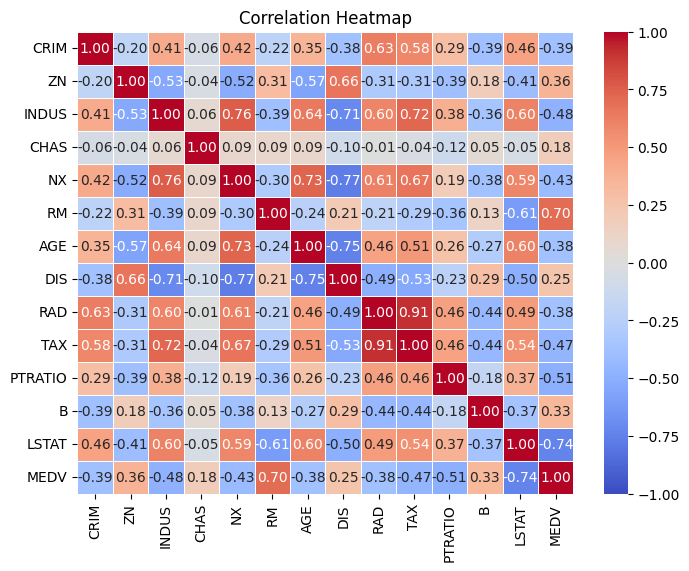

In [ ]:
corr = mydata.select_dtypes(include='number').corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f", linewidths=.5)
plt.title("Correlation Heatmap")
plt.show()

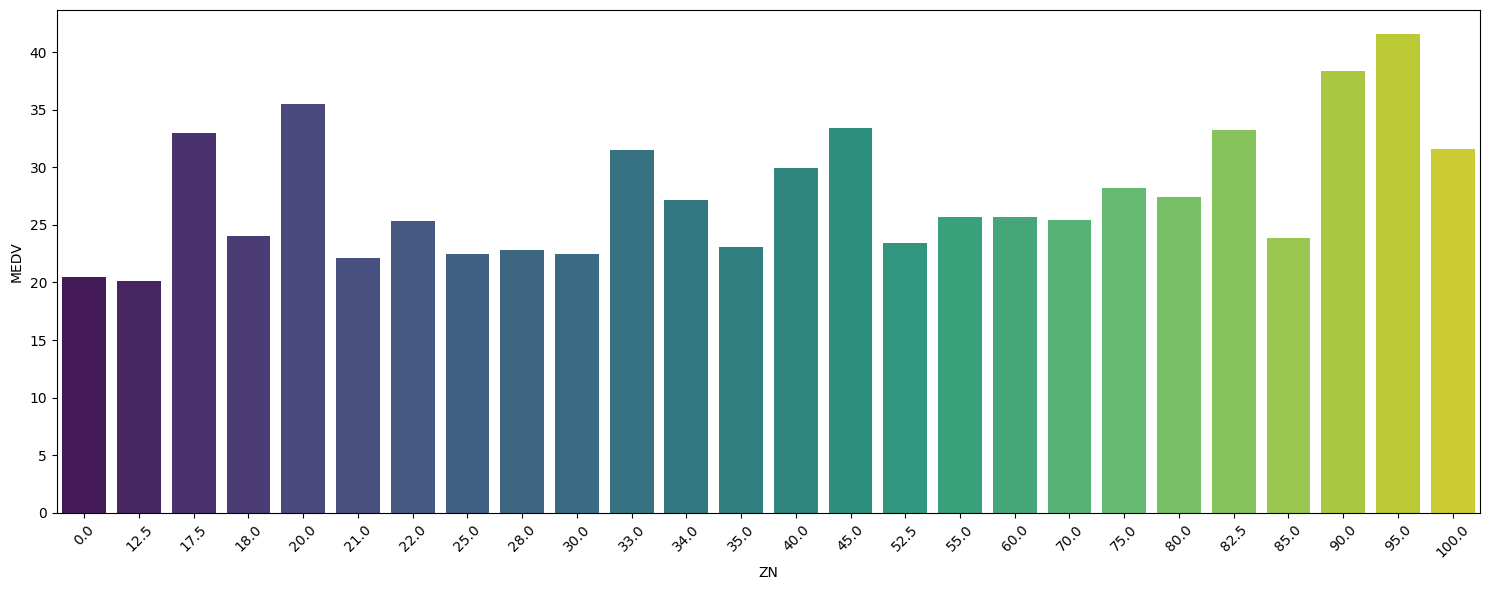

In [ ]:
zn_medv_mean=mydata.groupby("ZN")["MEDV"].mean().reset_index()
figure_size = (15, 6)
plt.figure(figsize=figure_size)
sns.barplot(x='ZN', y='MEDV', data=zn_medv_mean, palette='viridis')
plt.xticks(rotation=45)
plt.tight_layout()


In [ ]:
X = mydata.drop(columns=['MEDV'])
y=mydata['MEDV']

In [ ]:
X.shape
X.columns

Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT'],
      dtype='object')

In [ ]:
y.shape

(506,)

In [ ]:
###Step 5: divide the data intro train and testing
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.3, random_state=42)

In [ ]:
X_train.shape

(354, 13)

In [ ]:
y_train.shape

(354,)

In [ ]:
#step6: Applying ML Algo
from sklearn.linear_model import LinearRegression

lr=LinearRegression()
lr_model=lr.fit(X_train,y_train)

In [ ]:
lr_model.coef_

array([-1.33470103e-01,  3.58089136e-02,  4.95226452e-02,  3.11983512e+00,
       -1.54170609e+01,  4.05719923e+00, -1.08208352e-02, -1.38599824e+00,
        2.42727340e-01, -8.70223437e-03, -9.10685208e-01,  1.17941159e-02,
       -5.47113313e-01])

In [ ]:
lr_model.intercept_

np.float64(31.63108403569261)

In [ ]:
y_pred_lr=lr.predict(X_test)

In [ ]:
from sklearn.metrics import root_mean_squared_error as rmse
rmse_lr=root_mean_squared_error(y_test,y_pred_lr)
rmse_lr

4.63868992617283

In [ ]:
from sklearn.metrics import r2_score as r2
r2_lr=r2(y_test,y_pred_lr)
r2_lr


0.711226005748492

In [ ]:
##decision tree regression
from sklearn.tree import DecisionTreeRegressor

# Initialize and fit the model
dt = DecisionTreeRegressor()
dt_model = dt.fit(X_train, y_train)

# Predict and evaluate
y_pred_dt = dt.predict(X_test)

rmse_dtr=root_mean_squared_error(y_test,y_pred_dt)
r2_dtr=r2(y_test,y_pred_dt)

In [ ]:
r2_dtr

0.8403071240614624

In [ ]:
rmse_dtr

3.4495232317402635

In [ ]:
## Random Forest Regression
from sklearn.ensemble import RandomForestRegressor

rf_model = rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

rmse_rf = root_mean_squared_error(y_test, y_pred_rf)
r2_rf = r2(y_test, y_pred_rf)

In [ ]:
r2_rf

0.8708997131330258

In [ ]:
rmse_rf


3.1015579977098433